# Inspect Yandex OCR vs target — one image

Shows the exact `ref`/`hyp` strings fed to `jiwer` (raw and after `page_text`), the CER/WER, and a word-level diff — to catch bogus mismatches (empty prediction, printed header text Yandex read, `[?]` in the target, wrong page).

Reuses `page_text` / `yandex_fulltext` from the eval script, so the comparison is **identical**. Already-evaluated pages are read from `./.yandex_cache` (no creds needed); on a cache miss it calls Yandex — set the creds in the setup cell then.

In [4]:
import os, sys
from pathlib import Path

import jiwer
import matplotlib.pyplot as plt
from PIL import Image

# repo root (holds kaliningrad_essays_eval_yandex.py)
here = Path.cwd()
ROOT = here if (here / "kaliningrad_essays_eval_yandex.py").exists() else here.parent
sys.path.insert(0, str(ROOT))
from kaliningrad_essays_eval_yandex import page_text, yandex_fulltext

# only needed if the page isn't cached yet:
# os.environ["YANDEX_API_KEY"]   = "..."
# os.environ["YANDEX_FOLDER_ID"] = "..."

DATA = ROOT / "data/kaliningrad_essays"   # eval root, so cache keys match a full eval run
MODEL = "handwritten"        # handwritten | page | page-column-sort
print("ready | data:", DATA)

ready | data: /workspace/HDD/handwriting-recognition/data/kaliningrad_essays


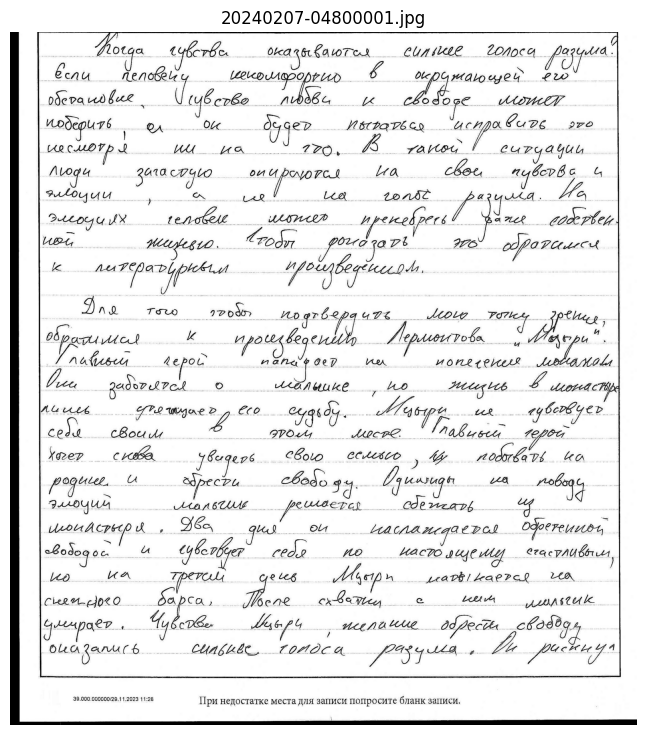


===== TARGET raw (.txt) (1069 chars) =====
Когда чувства оказываются сильнее голоса разума?
Если человеку некомфортно в окружающей его
обстановке, чувство любви к свободе может
победить, и он будет пытаться исправить это
несмотря ни на что. В такой ситуации
люди зачастую опираются на свои чувства и
эмоции, а не на голос разума. На
эмоциях человек может пренебречь даже собствен-
ной жизнью. Чтоб доказать это обратимся
к литературным произведениям.
Для того чтоб подтвердить мою точку зрения,
обратимся к произведению Лермонтова „Мцыри".
Главный герой попадает на попечение монахам.
Они заботятся о мальчике, но жизнь в монастыре
лишь утягощает его судьбу. Мцыри не чувствует
себя своим в этом месте. Главный герой
хочет снова увидеть свою семью, побывать на
родине и обрести свободу. Однажды на поводу
эмоций мальчик решается сбежать из
монастыря. Два дня он наслаждается обретенной
свободой и чувствует себя по настоящему счастливым,
но на третий день Мцыри натыкается на
снежного барса. После с

In [5]:
# >>> set the image to inspect, then run this cell <<<
IMAGE = DATA / "0253641946/20240207-04800001.jpg"

txt = IMAGE.with_suffix(".txt")
assert txt.exists(), f"no target .txt next to image: {txt}"
full = yandex_fulltext(IMAGE, DATA, os.environ.get("YANDEX_API_KEY", ""),
                       os.environ.get("YANDEX_FOLDER_ID", ""), MODEL)

ref_raw = txt.read_text(encoding="utf-8")
ref, hyp = page_text(ref_raw), page_text(full)

plt.figure(figsize=(13, 9)); plt.imshow(Image.open(IMAGE)); plt.axis("off"); plt.title(IMAGE.name); plt.show()

def block(title, s):
    print(f"\n===== {title} ({len(s)} chars) =====\n{s}")

block("TARGET raw (.txt)", ref_raw)
block("YANDEX fullText raw", full)
block("REF  -> page_text (fed to jiwer)", ref)
block("HYP  -> page_text (fed to jiwer)", hyp)

print("\n----- metrics -----")
print(f"ref: {len(ref)} chars, {len(ref.split())} words | hyp: {len(hyp)} chars, {len(hyp.split())} words")
print(f"CER = {jiwer.cer(ref, hyp):.4f}    WER = {jiwer.wer(ref, hyp):.4f}")

print("\n----- word diff (S=sub D=del I=ins) -----")
try:
    print(jiwer.visualize_alignment(jiwer.process_words(ref, hyp), skip_correct=True))
except Exception as e:
    print(f"(word diff unavailable: {e})")